# Imports

In [46]:
import sys
from pathlib import Path

# Get the current notebook's directory (using the current working directory)
NOTEBOOK_DIR = Path.cwd()

# Navigate up to the project root (assumes notebook is in ./notebooks)
ROOT_DIR = NOTEBOOK_DIR.parent

# Path to the 'src' directory
SRC_DIR = ROOT_DIR / "src"

# Add 'src' to Python path so we can import modules like 'data.load_data'
sys.path.append(str(SRC_DIR))


In [96]:
import numpy                 as np
import pandas                as pd
%matplotlib inline
import matplotlib.pyplot     as plt
import seaborn               as sns
import umap.umap_            as umap
import sklearn.preprocessing as pp
import networkx              as nx
import warnings
import re

from data.load_data             import load_ecommerce_data
from features.transform_columns import to_snake_case_columns

from yellowbrick.cluster        import KElbowVisualizer, SilhouetteVisualizer
from sklearn.metrics            import silhouette_score, silhouette_samples
from plotly                     import express as px
from sklearn.decomposition      import PCA
from sklearn.manifold           import TSNE
from sklearn.ensemble           import RandomForestRegressor
from scipy.cluster              import hierarchy as hc
from sklearn.cluster            import KMeans, DBSCAN
from sklearn.mixture            import GaussianMixture


warnings.filterwarnings('ignore')


# Load Dataset

In [48]:
# Load data
df_raw = load_ecommerce_data("../data/raw/Ecommerce.csv")

df_raw

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,29-Nov-16,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,29-Nov-16,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,29-Nov-16,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,29-Nov-16,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,29-Nov-16,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,7-Dec-17,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,7-Dec-17,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,7-Dec-17,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,7-Dec-17,4.15,12680.0,France


# <font color='blue'> 📊  1.0 Data Description

## <span style="color:blue">1.1</span> Rename Columns

In [49]:
df1 = df_raw.copy()

In [50]:
df1 = to_snake_case_columns(df1)
df1.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,29-Nov-16,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,29-Nov-16,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,29-Nov-16,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,29-Nov-16,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,29-Nov-16,3.39,17850.0,United Kingdom


## <span style="color:blue">1.2</span> Data Dimensions

In [51]:
print(f'Number of rows: {df1.shape[0]}')
print(f'Number of columns: {df1.shape[1]}')

Number of rows: 541909
Number of columns: 8


## <span style="color:blue">1.3</span> Data Types

In [52]:
df1.dtypes

invoice_no       object
stock_code       object
description      object
quantity          int64
invoice_date     object
unit_price      float64
customer_id     float64
country          object
dtype: object

## <span style="color:blue">1.4</span> Check NA

In [53]:
df1.isna().sum()

invoice_no           0
stock_code           0
description       1454
quantity             0
invoice_date         0
unit_price           0
customer_id     135080
country              0
dtype: int64

## <span style="color:blue">1.5</span> Replace NA

In [54]:
# Get NA records
df_missing = df1.loc[df1['customer_id'].isna(), :]

# Get NOT NA records
df_not_missing  = df1.loc[~df1['customer_id'].isna(), :]

In [55]:
# create auxiliary dataframe with missing customer_id
df_backup = pd.DataFrame(df_missing['invoice_no'].drop_duplicates())
df_backup['customer_id'] = np.arange(19000, 19000 + len(df_backup), 1)

# merge auxiliary dataframe with df_missing
df_missing.drop(columns=['customer_id'], inplace=True)
df_missing = df_missing.merge(df_backup, on='invoice_no', how='left')

# concatenate df_not_missing and df_missing
df1 = pd.concat([df_not_missing, df_missing], axis=0)

df1.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,29-Nov-16,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,29-Nov-16,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,29-Nov-16,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,29-Nov-16,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,29-Nov-16,3.39,17850.0,United Kingdom


In [56]:
df1.isna().sum()

invoice_no         0
stock_code         0
description     1454
quantity           0
invoice_date       0
unit_price         0
customer_id        0
country            0
dtype: int64

## <span style="color:blue">1.6</span> Change dtype

In [57]:
# invoice_date
df1['invoice_date'] = pd.to_datetime(df1['invoice_date'], format='%d-%b-%y')

# customer id
df1['customer_id'] = df1['customer_id'].astype(int)

df1.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2016-11-29,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2016-11-29,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2016-11-29,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2016-11-29,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2016-11-29,3.39,17850,United Kingdom


In [58]:
df1.dtypes

invoice_no              object
stock_code              object
description             object
quantity                 int64
invoice_date    datetime64[ns]
unit_price             float64
customer_id              int64
country                 object
dtype: object

## <span style="color:blue">1.7</span> Descriptive Statistics

In [59]:
num_attributes = df1.select_dtypes(include=['int64', 'float64'])
cat_attributes = df1.select_dtypes(exclude=['int64', 'float64', 'datetime64[ns]'])

### <span style="color:blue">1.7.1</span> Numerical Attributes

In [60]:
# Calculate all desired statistics at once (central and dispersion)
stats = pd.DataFrame({
    'mean': num_attributes.mean(),
    'median': num_attributes.median(),
    'std': num_attributes.std(),
    'min': num_attributes.min(),
    'max': num_attributes.max(),
    'range': num_attributes.max() - num_attributes.min(),
    'skew': num_attributes.skew(),
    'kurtosis': num_attributes.kurtosis()
})

# Display the statistics
print("Numerical Attributes Statistics:")
stats

Numerical Attributes Statistics:


,mean,median,std,min,max,range,skew,kurtosis
quantity,9.552250,3.00,218.081158,-80995.00,80995.0,161990.00,-0.264076,119769.160031
unit_price,4.611114,2.08,96.759853,-11062.06,38970.0,50032.06,186.506972,59005.719097
customer_id,16688.840453,16249.00,2911.411352,12346.00,22709.0,10363.00,0.487449,-0.804287


### <span style="color:blue">1.7.2</span> Categorical Attributes

In [61]:
cat_attributes.head()

,invoice_no,stock_code,description,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
1,536365,71053,WHITE METAL LANTERN,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,United Kingdom


In this first cycle, the Country column will not be used.

# <font color='blue'> 🧹2.0 Data Filtering

In [62]:
df2 = df1.copy()

In [63]:
df2.dtypes

invoice_no              object
stock_code              object
description             object
quantity                 int64
invoice_date    datetime64[ns]
unit_price             float64
customer_id              int64
country                 object
dtype: object

In [64]:

# === Numerical attributes ===
df2 = df2.loc[df2['unit_price'] >= 0.04, :]

# === Categorical attributes ====
df2 = df2[~df2['stock_code'].isin( ['POST', 'D', 'DOT', 'M', 'S', 'AMAZONFEE', 'm', 'DCGSSBOY', 'DCGSSGIRL', 'PADS', 'B', 'CRUK'] ) ]

# Remove column description
df2.drop(columns=['description'], inplace=True)

# country
df2 = df2[~df2['country'].isin(['European Community', 'Unspecified'])]

# bad users
df2 = df2[~df2['customer_id'].isin( [16446] )]

# quantity
df2_returns = df2.loc[df2['quantity'] < 0, :]
df2_purchases = df2.loc[df2['quantity'] > 0, :]


# <font color='blue'> ⚙️ 3.0 Feature Engineering

In [65]:
df3= df2.copy()

In [66]:
df3.shape

(536139, 7)

## <span style="color:blue">3.1</span> Feature Creation

In [67]:
# data reference
df_ref = (
    df3.drop( ['invoice_no', 'stock_code', 'quantity', 'invoice_date', 'unit_price', 'country'], axis=1 )
    .drop_duplicates( ignore_index=True )
)

### <span style="color:blue">3.1.1 </span> Gross Revenue



In [68]:
# Gross Revenue - Quantity * Unit Price
df2_purchases.loc[:, 'gross_revenue'] = df2_purchases.loc[:, 'quantity'] * df2_purchases.loc[:, 'unit_price']

# Monetary
df_monetary = df2_purchases.loc[:, ['customer_id', 'gross_revenue']].groupby( 'customer_id' ).sum().reset_index()
df_ref = pd.merge( df_ref, df_monetary, on='customer_id', how='left' )
df_ref.isna().sum()

customer_id       0
gross_revenue    91
dtype: int64

### <span style="color:blue">3.1.2</span> Recency - Day from Last Purchase

In [69]:
# Recency - Last Day Purchase
df_recency = (
    df2_purchases[['customer_id', 'invoice_date']]
    .groupby('customer_id').max().reset_index()
    .rename(columns={'invoice_date': 'last_day_purchase'})
)

df_recency['recency_days'] = (df2_purchases['invoice_date'].max() - df_recency['last_day_purchase']).dt.days
df_ref = pd.merge(df_ref, df_recency[['customer_id', 'recency_days']], on='customer_id', how='left')
df_ref.isna().sum()

customer_id       0
gross_revenue    91
recency_days     91
dtype: int64

### <span style="color:blue">3.1.5</span> Quantity of products purchased 

In [70]:
# Numero de produtos
df_freq = df2_purchases[['customer_id', 'stock_code']].\
            groupby( 'customer_id' ).count().\
            reset_index().\
            rename( columns={'stock_code': 'qtde_products'} )

df_ref = pd.merge( df_ref, df_freq, on='customer_id', how='left' )
df_ref.isna().sum()

customer_id       0
gross_revenue    91
recency_days     91
qtde_products    91
dtype: int64

### <span style="color:blue">3.1.8</span> Purchase Frequency

In [71]:
# Step 1: Create an auxiliary DataFrame with purchase activity summary for each customer
df_aux = (
    df2_purchases[['customer_id', 'invoice_no', 'invoice_date']]  # Select relevant columns
    .drop_duplicates()  # Remove duplicate purchase records
    .groupby('customer_id')  # Group by customer
    .agg(
        max_=('invoice_date', 'max'),  # Last purchase date
        min_=('invoice_date', 'min'),  # First purchase date
        days_=('invoice_date', lambda x: (x.max() - x.min()).days + 1),  # Total active days
        buy_=('invoice_no', 'count')  # Total number of purchases
    )
    .reset_index()
)

# Step 2: Calculate frequency of purchases (buys per day)
df_aux['frequency'] = df_aux.apply(
    lambda row: row['buy_'] / row['days_'] if row['days_'] != 0 else 0,
    axis=1
)

# Step 3: Merge frequency information into the reference DataFrame
df_ref = pd.merge(
    df_ref,
    df_aux[['customer_id', 'frequency']],
    on='customer_id',
    how='left'  # Keep all rows from df_ref
)

# Step 4: Check for missing values after the merge
df_ref.isna().sum()

customer_id       0
gross_revenue    91
recency_days     91
qtde_products    91
frequency        91
dtype: int64

### <span style="color:blue">3.1.9</span> Returns

In [72]:
# Calculate total number of returned items per customer
df_returns = (
    df2_returns[['customer_id', 'quantity']]
    .groupby('customer_id')
    .sum()
    .reset_index()
    .rename(columns={'quantity': 'qtde_returns'})
)

# Convert return quantities to positive values
df_returns['qtde_returns'] = df_returns['qtde_returns'].abs()

# Merge return data into the reference DataFrame
df_ref = pd.merge(df_ref, df_returns, on='customer_id', how='left')

# Fill missing return quantities with 0 (i.e., no returns)
df_ref['qtde_returns'] = df_ref['qtde_returns'].fillna(0)

# Check for any remaining missing values in the DataFrame
df_ref.isna().sum()

customer_id       0
gross_revenue    91
recency_days     91
qtde_products    91
frequency        91
qtde_returns      0
dtype: int64

# <font color='blue'> 📈 4.0 Exploratory Data Analysis

In [73]:
df4 = df_ref.dropna().copy()
df4.isna().sum()

customer_id      0
gross_revenue    0
recency_days     0
qtde_products    0
frequency        0
qtde_returns     0
dtype: int64

# <font color='blue'> 🎯 5.0 Feature Spotlight: Selecting the Best Predictors

In [74]:
cols_selected = ['customer_id', 'gross_revenue', 'recency_days', 'qtde_products', 'frequency', 'qtde_returns'] 

df5 = df4[cols_selected].copy()
df5.head()

,customer_id,gross_revenue,recency_days,qtde_products,frequency,qtde_returns
0,17850,5391.21,372.0,297.0,17.000000,40.0
1,13047,3232.59,56.0,171.0,0.028302,35.0
2,12583,6705.38,2.0,232.0,0.040323,50.0
3,13748,948.25,95.0,28.0,0.017921,0.0
4,15100,876.00,333.0,3.0,0.073171,22.0


In [75]:
df5.shape

(5695, 6)

# <font color='blue'> 🛠️ 6.0 Data Transforming

In [76]:
df6 = df5.copy()

In [77]:
# Initialize MinMaxScalers
mm_gross_revenue = pp.MinMaxScaler()
mm_recency_days = pp.MinMaxScaler()
mm_qtde_products = pp.MinMaxScaler()
mm_frequency = pp.MinMaxScaler()
mm_qtde_returns = pp.MinMaxScaler()

# Apply MinMaxScaler only on selected numerical columns
df6['gross_revenue'] = mm_gross_revenue.fit_transform(df6[['gross_revenue']])
df6['recency_days'] = mm_recency_days.fit_transform(df6[['recency_days']])
df6['qtde_products'] = mm_qtde_products.fit_transform(df6[['qtde_products']])
df6['frequency'] = mm_frequency.fit_transform(df6[['frequency']])
df6['qtde_returns'] = mm_qtde_returns.fit_transform(df6[['qtde_returns']])

cols_selected = ['customer_id', 'gross_revenue', 'recency_days', 'qtde_products', 'frequency', 'qtde_returns'] 

# Verificar resultado
df6[cols_selected].head()

,customer_id,gross_revenue,recency_days,qtde_products,frequency,qtde_returns
0,17850,0.019312,0.997319,0.037770,1.000000,0.000539
1,13047,0.011579,0.150134,0.021692,0.001345,0.000472
2,12583,0.024020,0.005362,0.029476,0.002052,0.000674
3,13748,0.003396,0.254692,0.003445,0.000734,0.000000
4,15100,0.003137,0.892761,0.000255,0.003985,0.000296


# <font color='blue'> 🎯 7.0 Study of the Space of Embeddings

In [80]:
df7 = df6.copy()

In [81]:
# X receives all columns from df6 except 'customer_id'
X = df7.drop(columns=['customer_id']).copy()

# Check result
X.head()

,gross_revenue,recency_days,qtde_products,frequency,qtde_returns
0,0.019312,0.997319,0.037770,1.000000,0.000539
1,0.011579,0.150134,0.021692,0.001345,0.000472
2,0.024020,0.005362,0.029476,0.002052,0.000674
3,0.003396,0.254692,0.003445,0.000734,0.000000
4,0.003137,0.892761,0.000255,0.003985,0.000296


## 7.1 PCA

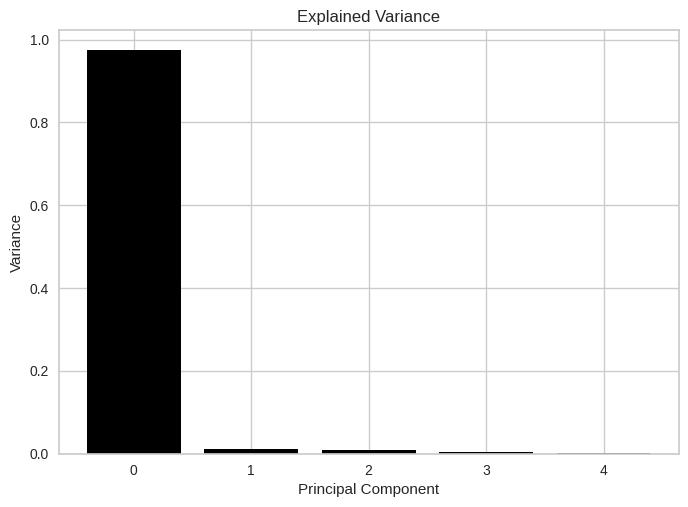

In [85]:
pca = PCA(n_components=X.shape[1])

principal_components = pca.fit_transform(X)

# plot explained variables
features = range(pca.n_components_)

plt.bar(features, pca.explained_variance_ratio_, color='black')
plt.xlabel('Principal Component')
plt.ylabel('Variance')
plt.title('Explained Variance')
plt.show()

# pca components
df_pca = pd.DataFrame(principal_components)

<Axes: xlabel='0', ylabel='1'>

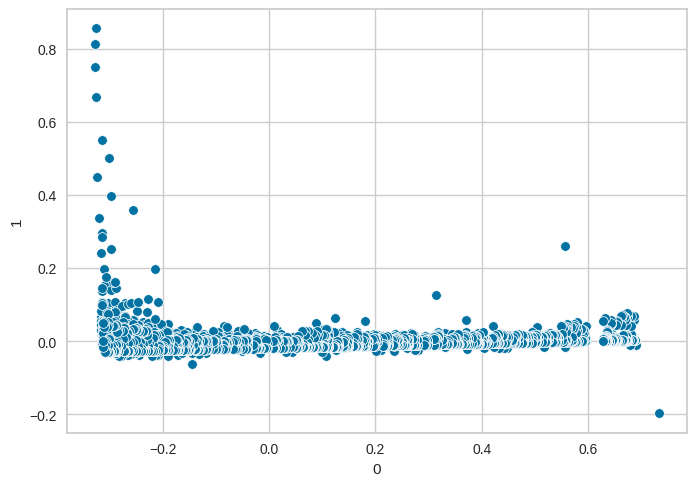

In [86]:
sns.scatterplot(x=0, y=1, data=df_pca)

### ⚠️ Why This PCA Distribution Is Not Suitable for Clustering

1. ❌ **No Clear Separable Groups**
   - The data forms a dense triangular cloud with no visible gaps or natural boundaries.
   - Points lie on a continuous gradient, not in distinct clusters.
   - Clustering algorithms (e.g., K-Means, DBSCAN) work best with well-separated, compact groups.

2. ❌ **High Overlap of Points**
   - Central overlap makes it difficult to distinguish cluster boundaries.
   - This can lead to arbitrary or poor clustering results.

3. ❌ **PCA Doesn’t Optimize for Clustering**
   - PCA focuses on capturing variance, not on separating clusters.
   - The top components may not reflect the actual cluster structure.
   - Variance directions might cut across potential groupings.

## 7.2 UMAP

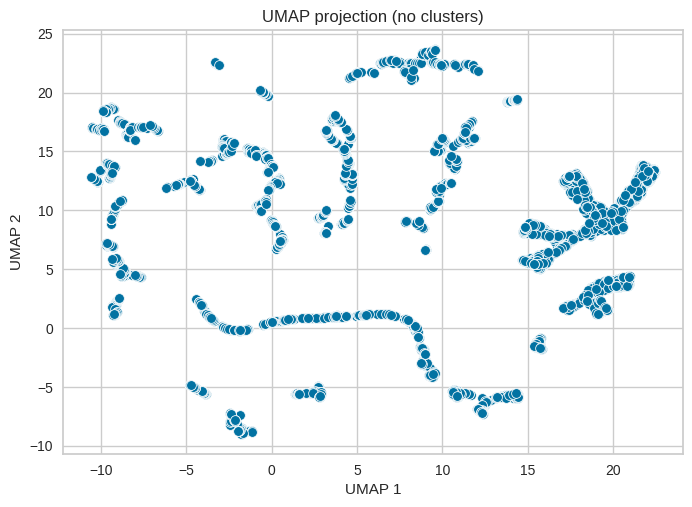

In [87]:
# Fit UMAP and transform the data
reducer = umap.UMAP(random_state=42)       # Initialize UMAP with fixed random seed
embedding = reducer.fit_transform(X)       # Fit UMAP on the data and transform it into 2D

# Create a new DataFrame with the UMAP embeddings
df_umap = pd.DataFrame({
    'embedding_x': embedding[:, 0],        # First UMAP component (x-axis)
    'embedding_y': embedding[:, 1]         # Second UMAP component (y-axis)
})

# Plot the UMAP results using seaborn (no clusters yet)
sns.scatterplot(
    x='embedding_x', 
    y='embedding_y', 
    data=df_umap
)

# Show the plot
plt.title('UMAP projection (no clusters)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

## 7.3 t-SNE

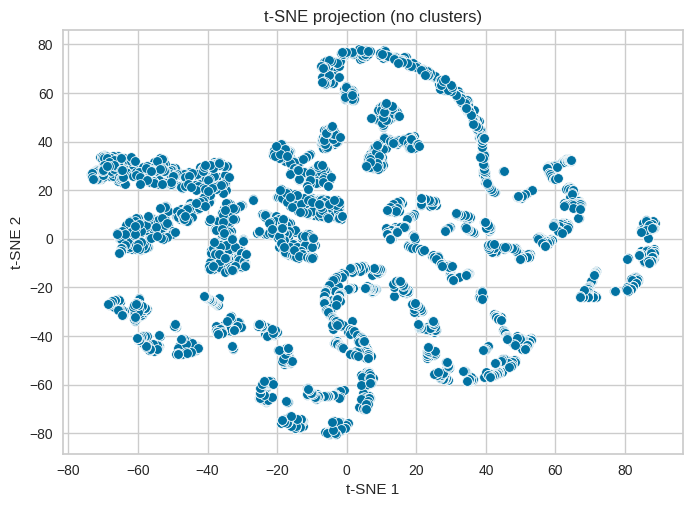

In [88]:
# Fit t-SNE and transform the data
tsne = TSNE(n_components=2, random_state=42, n_jobs=-1)   # Initialize t-SNE to reduce to 2 dimensions
embedding = tsne.fit_transform(X)              # Fit and transform the data (X should be scaled and 2D)

# Create a new DataFrame with the t-SNE embeddings
df_tsne = pd.DataFrame({
    'embedding_x': embedding[:, 0],            # First t-SNE component (x-axis)
    'embedding_y': embedding[:, 1]             # Second t-SNE component (y-axis)
})

# Plot the t-SNE results using seaborn (no clusters yet)
sns.scatterplot(
    x='embedding_x', 
    y='embedding_y', 
    data=df_tsne
)

# Show the plot
plt.title('t-SNE projection (no clusters)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

## 7.4 Tree-Based Method

In [89]:
# training dataset
X = df7.drop(columns=['customer_id', 'gross_revenue'], axis=1)
y = df7['gross_revenue']

# model definition
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# model training
rf_model.fit(X, y)

# Leaf
df_leaf = pd.DataFrame(rf_model.apply(X))

df_leaf.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,6608,6964,6489,6532,6900,6946,6910,6749,6948,6579,...,6507,6461,6777,6636,6348,6434,6500,6951,6655,6726
1,6491,6046,6375,6320,6029,5756,6788,6676,6281,6397,...,6255,6404,5502,6248,6104,6362,6410,6334,6530,5964
2,6789,6868,6599,6271,6813,6880,6840,6633,6444,6559,...,6498,6548,6422,6293,5541,5446,6596,6381,6595,6892
3,707,1298,755,427,1213,441,1164,445,1187,850,...,852,629,906,621,614,938,505,637,653,725
4,519,315,498,604,489,1008,66,988,81,1046,...,84,756,101,199,92,74,1036,504,779,509


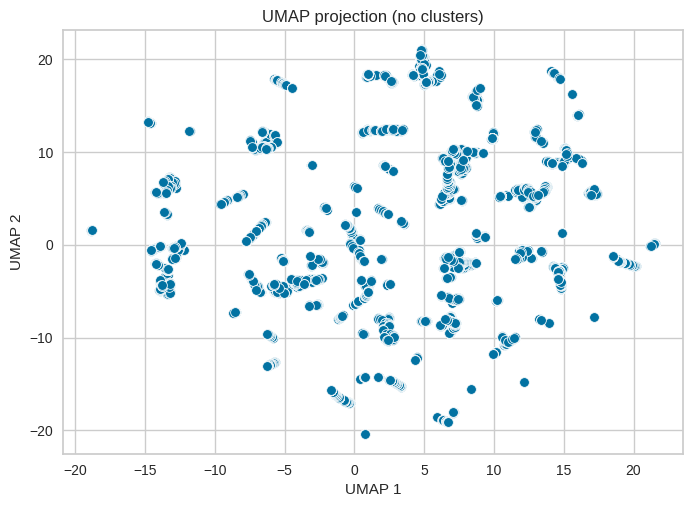

In [90]:
# Apply UMAP in df_leaf

# Fit UMAP and transform the data
reducer = umap.UMAP(random_state=42)       # Initialize UMAP with fixed random seed
embedding = reducer.fit_transform(df_leaf)       # Fit UMAP on the data and transform it into 2D

# Create a new DataFrame with the UMAP embeddings
df_umap_tree = pd.DataFrame({
    'embedding_x': embedding[:, 0],        # First UMAP component (x-axis)
    'embedding_y': embedding[:, 1]         # Second UMAP component (y-axis)
})

# Plot the UMAP results using seaborn (no clusters yet)
sns.scatterplot(
    x='embedding_x', 
    y='embedding_y', 
    data=df_umap_tree
)

# Show the plot
plt.title('UMAP projection (no clusters)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

# <font color='blue'> 🔍 8.0 Hyperparameter Fine-Tuning

In [102]:
# Dictionary containing all embedding spaces
embedding_spaces = {
    "Original Feature Space": X.copy(),
    "TSNE (2D)": df_tsne.copy(),
    "UMAP (2D)": df_umap.copy(),
    "Leaf Embedding + UMAP (2D)": df_umap_tree.copy(),
}

In [103]:
clusters = np.arange(2, 21)
clusters

array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20])


Evaluating: Original Feature Space


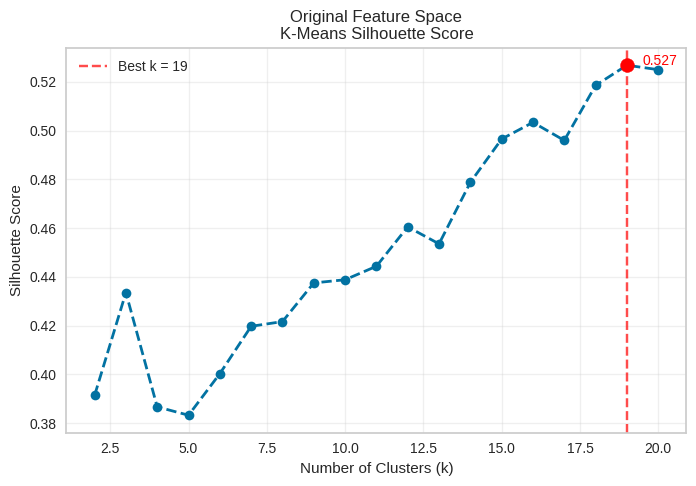


Evaluating: TSNE (2D)


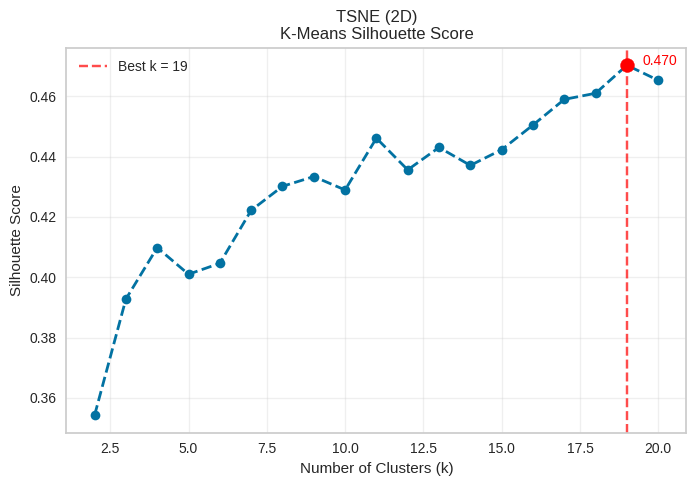


Evaluating: UMAP (2D)


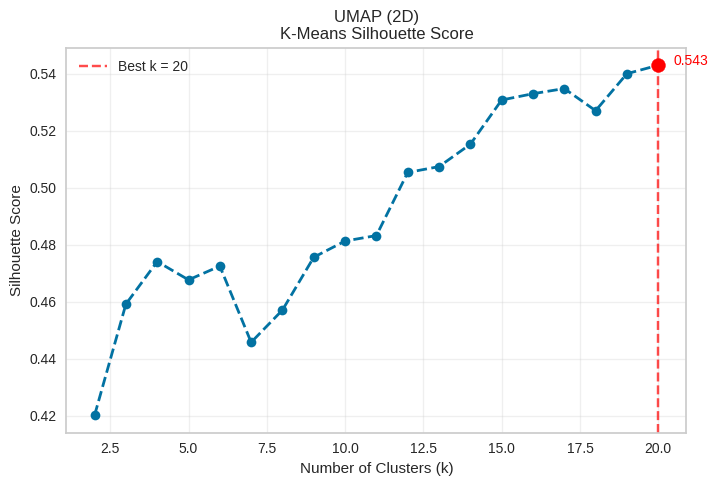


Evaluating: Leaf Embedding + UMAP (2D)


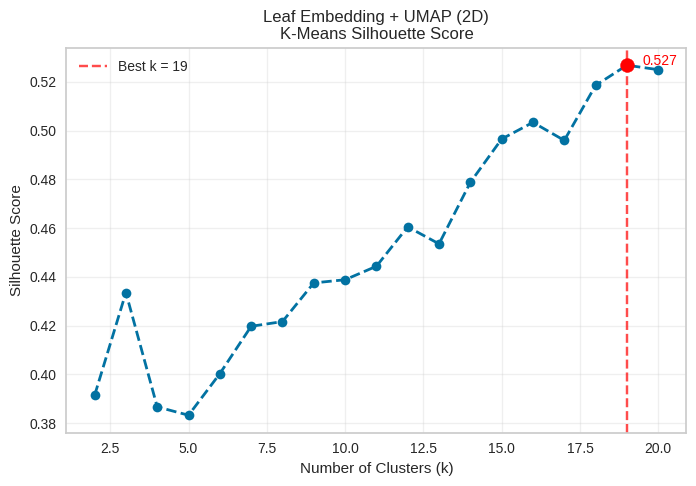

In [117]:
# DataFrame to store all silhouette scores
results = pd.DataFrame()

# Loop through each embedding space
for space_name, X_space in embedding_spaces.items():

    print(f"\nEvaluating: {space_name}")

    silhouette_scores = []

    # Test all values of k
    for k in clusters:

        # Create and fit K-Means
        model = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )

        labels = model.fit_predict(X_space)

        # Compute silhouette score
        score = silhouette_score(
            X_space,
            labels,
            metric="euclidean"
        )

        silhouette_scores.append(score)

    # Find best k
    best_index = np.argmax(silhouette_scores)
    best_k = clusters[best_index]
    best_score = silhouette_scores[best_index]

    # Save results
    # Append to results
    results = pd.concat([results, pd.DataFrame({space_name: silhouette_scores}).T])

    # ==========================
    # Plot
    # ==========================
    plt.figure(figsize=(8,5))

    plt.plot(
        clusters,
        silhouette_scores,
        marker="o",
        linestyle="--",
        linewidth=2
    )

    plt.scatter(
        best_k,
        best_score,
        s=100,
        color="red",
        zorder=5
    )

    plt.axvline(
        best_k,
        linestyle="--",
        color="red",
        alpha=0.7,
        label=f"Best k = {best_k}"
    )

    plt.text(
        best_k + 0.5,
        best_score,
        f"{best_score:.3f}",
        fontsize=10,
        color="red"
    )

    plt.title(f"{space_name}\nK-Means Silhouette Score")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Silhouette Score")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.show()

In [120]:
results.style.highlight_max( color='mediumblue', axis=1 )

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
Original Feature Space,0.391411,0.433597,0.386721,0.383287,0.400335,0.419761,0.421696,0.437554,0.438860,0.444381,0.460559,0.453574,0.478791,0.496573,0.503404,0.496002,0.518563,0.526848,0.525020
TSNE (2D),0.354227,0.392752,0.409816,0.400987,0.404607,0.422176,0.430144,0.433381,0.428943,0.446120,0.435608,0.443044,0.437091,0.442294,0.450477,0.458978,0.461013,0.470313,0.465315
UMAP (2D),0.420236,0.459197,0.474116,0.467705,0.472520,0.445806,0.457116,0.475639,0.481315,0.483242,0.505359,0.507417,0.515256,0.530768,0.532977,0.534786,0.527022,0.539999,0.542967
Leaf Embedding + UMAP (2D),0.391411,0.433597,0.386721,0.383287,0.400335,0.419761,0.421696,0.437554,0.438860,0.444381,0.460559,0.453574,0.478791,0.496573,0.503404,0.496002,0.518563,0.526848,0.525020


## <span style="color:blue">8.2</span> GMM


Evaluating: Original Feature Space


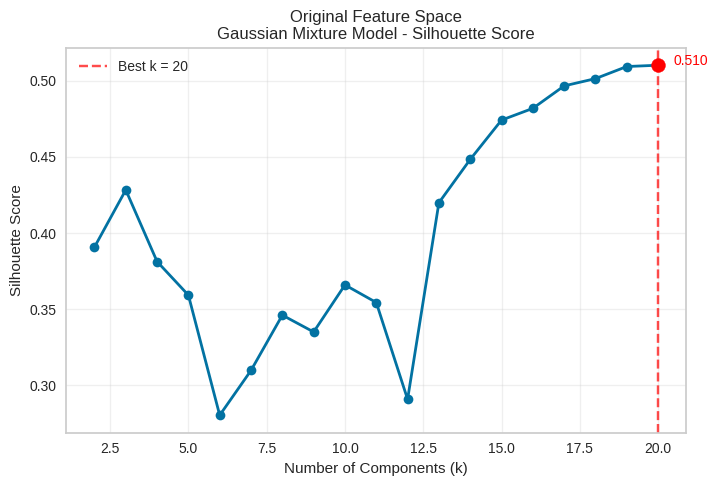


Evaluating: TSNE (2D)


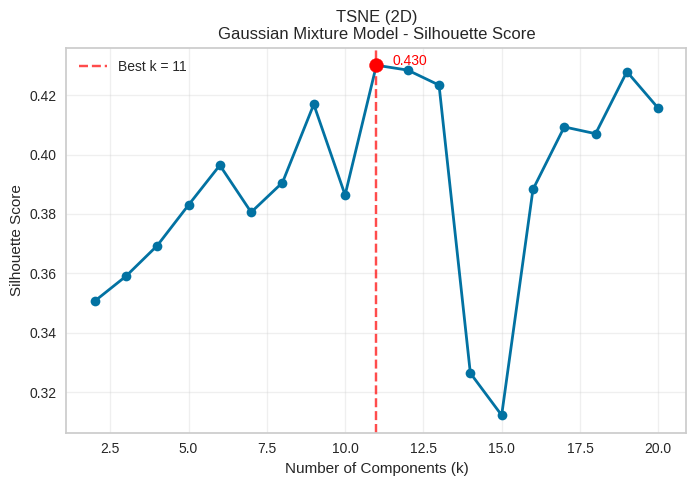


Evaluating: UMAP (2D)


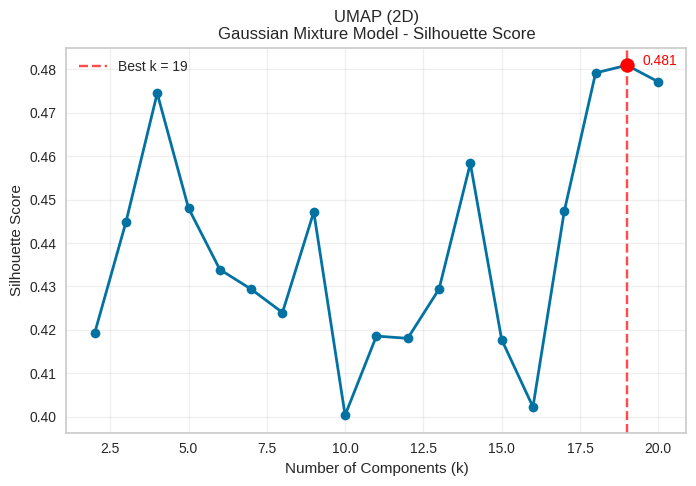


Evaluating: Leaf Embedding + UMAP (2D)


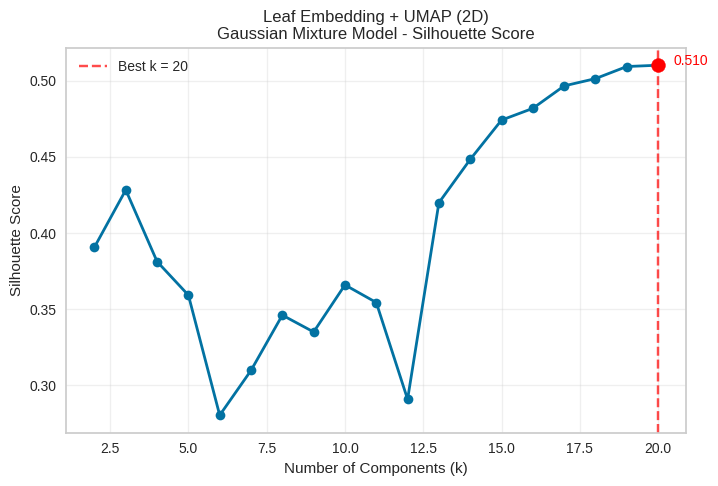

In [121]:
# DataFrame to store all silhouette scores
results = pd.DataFrame()

# Loop through each embedding space
for space_name, X_space in embedding_spaces.items():

    print(f"\nEvaluating: {space_name}")

    gmm_sil_list = []

    # Test all values of k
    for k in clusters:

        # Create Gaussian Mixture Model
        gmm_model = GaussianMixture(
            n_components=k,
            random_state=42
        )

        # Fit the model and predict labels
        labels = gmm_model.fit_predict(X_space)

        # Compute silhouette score
        score = silhouette_score(
            X_space,
            labels,
            metric="euclidean"
        )

        gmm_sil_list.append(score)

    # Find best k
    best_index = np.argmax(gmm_sil_list)
    best_k = clusters[best_index]
    best_score = gmm_sil_list[best_index]

    # Save results
    # Append to results
    results = pd.concat([results, pd.DataFrame({space_name: silhouette_scores}).T])

    # ==========================
    # Plot
    # ==========================
    plt.figure(figsize=(8,5))

    plt.plot(
        clusters,
        gmm_sil_list,
        marker="o",
        linewidth=2
    )

    plt.scatter(
        best_k,
        best_score,
        color="red",
        s=100,
        zorder=5
    )

    plt.axvline(
        best_k,
        color="red",
        linestyle="--",
        alpha=0.7,
        label=f"Best k = {best_k}"
    )

    plt.text(
        best_k + 0.5,
        best_score,
        f"{best_score:.3f}",
        color="red",
        fontsize=10
    )

    plt.title(f"{space_name}\nGaussian Mixture Model - Silhouette Score")
    plt.xlabel("Number of Components (k)")
    plt.ylabel("Silhouette Score")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.show()

In [122]:
results.style.highlight_max( color='mediumblue', axis=1 )

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
Original Feature Space,0.391411,0.433597,0.386721,0.383287,0.400335,0.419761,0.421696,0.437554,0.438860,0.444381,0.460559,0.453574,0.478791,0.496573,0.503404,0.496002,0.518563,0.526848,0.525020
TSNE (2D),0.391411,0.433597,0.386721,0.383287,0.400335,0.419761,0.421696,0.437554,0.438860,0.444381,0.460559,0.453574,0.478791,0.496573,0.503404,0.496002,0.518563,0.526848,0.525020
UMAP (2D),0.391411,0.433597,0.386721,0.383287,0.400335,0.419761,0.421696,0.437554,0.438860,0.444381,0.460559,0.453574,0.478791,0.496573,0.503404,0.496002,0.518563,0.526848,0.525020
Leaf Embedding + UMAP (2D),0.391411,0.433597,0.386721,0.383287,0.400335,0.419761,0.421696,0.437554,0.438860,0.444381,0.460559,0.453574,0.478791,0.496573,0.503404,0.496002,0.518563,0.526848,0.525020


## <span style="color:blue">8.3</span> Hierarchical Clustering


Evaluating: Original Feature Space


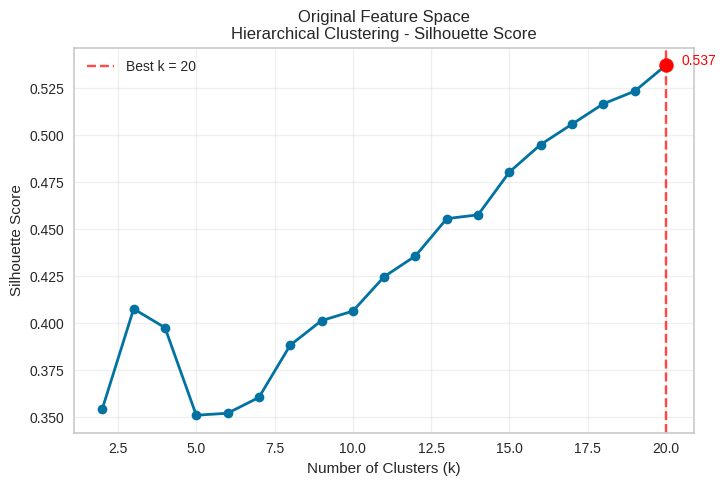


Evaluating: TSNE (2D)


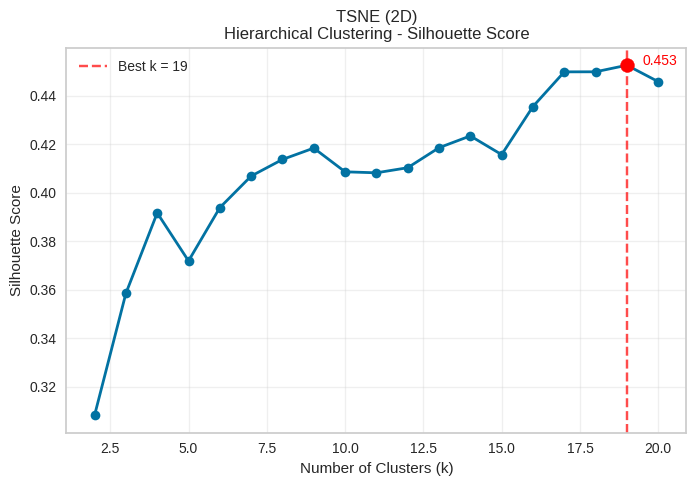


Evaluating: UMAP (2D)


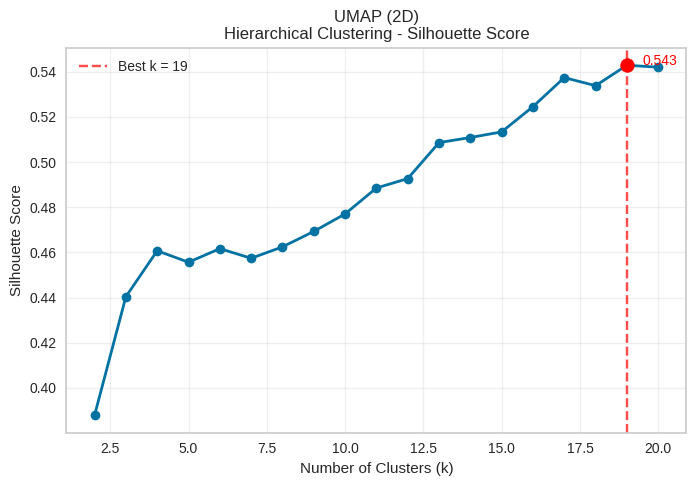


Evaluating: Leaf Embedding + UMAP (2D)


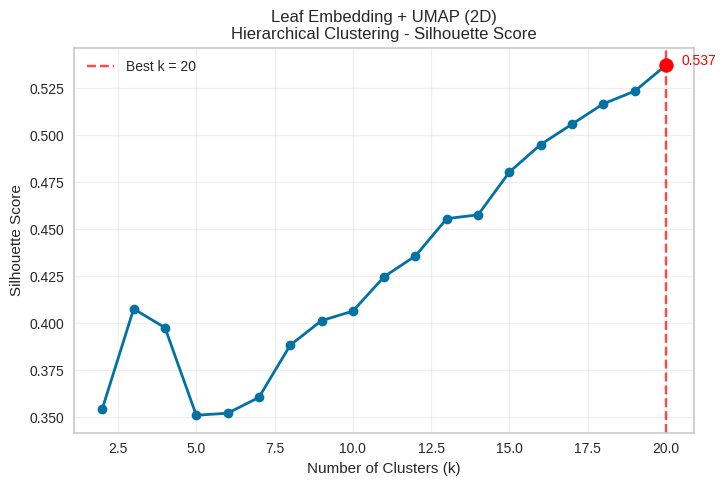

In [123]:
# DataFrame to store all silhouette scores
results = pd.DataFrame()

# Loop through each embedding space
for space_name, X_space in embedding_spaces.items():

    print(f"\nEvaluating: {space_name}")

    # Compute hierarchical clustering linkage
    hc_model = hc.linkage(
        X_space,
        method="ward",
        metric="euclidean"
    )

    hc_sil_list = []

    # Test all values of k
    for k in clusters:

        # Cut dendrogram into k clusters
        labels = hc.fcluster(
            hc_model,
            k,
            criterion="maxclust"
        )

        # Compute silhouette score
        score = silhouette_score(
            X_space,
            labels,
            metric="euclidean"
        )

        hc_sil_list.append(score)

    # Find best k
    best_index = np.argmax(hc_sil_list)
    best_k = clusters[best_index]
    best_score = hc_sil_list[best_index]

    # Save results
    results = pd.concat([results, pd.DataFrame({space_name: silhouette_scores}).T])

    # ==========================
    # Plot
    # ==========================
    plt.figure(figsize=(8, 5))

    plt.plot(
        clusters,
        hc_sil_list,
        marker="o",
        linewidth=2
    )

    plt.scatter(
        best_k,
        best_score,
        color="red",
        s=100,
        zorder=5
    )

    plt.axvline(
        best_k,
        color="red",
        linestyle="--",
        alpha=0.7,
        label=f"Best k = {best_k}"
    )

    plt.text(
        best_k + 0.5,
        best_score,
        f"{best_score:.3f}",
        color="red",
        fontsize=10
    )

    plt.title(f"{space_name}\nHierarchical Clustering - Silhouette Score")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Silhouette Score")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.show()

In [124]:
results.style.highlight_max( color='mediumblue', axis=1 )

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
Original Feature Space,0.391411,0.433597,0.386721,0.383287,0.400335,0.419761,0.421696,0.437554,0.438860,0.444381,0.460559,0.453574,0.478791,0.496573,0.503404,0.496002,0.518563,0.526848,0.525020
TSNE (2D),0.391411,0.433597,0.386721,0.383287,0.400335,0.419761,0.421696,0.437554,0.438860,0.444381,0.460559,0.453574,0.478791,0.496573,0.503404,0.496002,0.518563,0.526848,0.525020
UMAP (2D),0.391411,0.433597,0.386721,0.383287,0.400335,0.419761,0.421696,0.437554,0.438860,0.444381,0.460559,0.453574,0.478791,0.496573,0.503404,0.496002,0.518563,0.526848,0.525020
Leaf Embedding + UMAP (2D),0.391411,0.433597,0.386721,0.383287,0.400335,0.419761,0.421696,0.437554,0.438860,0.444381,0.460559,0.453574,0.478791,0.496573,0.503404,0.496002,0.518563,0.526848,0.525020


After evaluating multiple embedding spaces and clustering algorithms, I selected K-Means with the 2D UMAP embedding of the original feature space, as it achieved the best performance for the business requirement of 10 clusters.

Although higher silhouette scores were obtained with larger numbers of clusters, I chose k = 10 because it provides a more interpretable segmentation for business stakeholders.

In future CRISP-DM iterations, the solution can be improved by exploring additional features, alternative embedding methods, other clustering algorithms, and further hyperparameter tuning.

## <span style="color:blue">8.6</span> Silhouette Analysis

In [125]:
def plot_silhouette_facet(X, clusters, model_type="kmeans", **kwargs):
    """
    Generate silhouette plots for different values of k/clusters.

    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Input data.
    
    clusters : list
        List of cluster numbers to evaluate (ignored for DBSCAN).
    
    model_type : str
        Clustering algorithm: "kmeans", "gmm", "hc", or "dbscan".
    
    **kwargs :
        Additional parameters passed to the clustering algorithm.
    """

    n_cols = 2
    n_rows = int(np.ceil(len(clusters) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
    axes = axes.flatten()

    for idx, k in enumerate(clusters):

        # --- fit model based on type ---
        if model_type == "kmeans":
            model = KMeans(n_clusters=k, random_state=42, **kwargs).fit(X)
            labels = model.labels_

        elif model_type == "gmm":
            model = GaussianMixture(n_components=k, random_state=42, **kwargs).fit(X)
            labels = model.predict(X)

        elif model_type == "hc":
            hc_model = hc.linkage(X, method=kwargs.get("method", "ward"))
            labels = hc.fcluster(hc_model, k, criterion='maxclust')

        elif model_type == "dbscan":
            model = DBSCAN(**kwargs).fit(X)
            labels = model.labels_

            # skip silhouette if only 1 cluster found
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            if n_clusters <= 1:
                print(f"DBSCAN with params {kwargs} found only one cluster. Skipping silhouette.")
                continue
            k = None  # DBSCAN does not use fixed k

        else:
            raise ValueError("Invalid model_type. Choose from 'kmeans', 'gmm', 'hc', 'dbscan'.")

        # --- silhouette metrics ---
        ss = silhouette_score(X, labels)
        sample_silhouette_values = silhouette_samples(X, labels)

        # effective number of clusters (for plotting)
        k_effective = len(np.unique(labels)) if model_type == "dbscan" else k

        ax = axes[idx]
        ax.set_xlim([-0.1, 1])
        ax.set_ylim([0, len(X) + (k_effective + 1) * 10])

        y_lower = 10
        for i, cluster_id in enumerate(np.unique(labels), start=1):
            ith_values = sample_silhouette_values[labels == cluster_id]
            ith_values.sort()

            size_cluster = ith_values.shape[0]
            y_upper = y_lower + size_cluster

            cmap = plt.cm.get_cmap("Spectral")
            color = cmap(float(i) / k_effective)
            ax.fill_betweenx(np.arange(y_lower, y_upper),
                             0, ith_values,
                             facecolor=color, edgecolor=color, alpha=0.7)

            ax.text(-0.05, y_lower + 0.5 * size_cluster, str(cluster_id))
            y_lower = y_upper + 10

        # vertical line for avg silhouette
        ax.axvline(x=ss, color="red", linestyle="--")

        # titles and labels
        if model_type == "dbscan":
            title = f"DBSCAN (eps={kwargs.get('eps')}, min_samples={kwargs.get('min_samples')})\nMean silhouette={ss:.3f}"
        else:
            title = f"{model_type.upper()} k={k}\nMean silhouette={ss:.3f}"

        ax.set_title(title)
        ax.set_xlabel("Silhouette coefficient")
        ax.set_ylabel("Clusters")
        ax.set_yticks([])
        ax.set_xticks(np.linspace(-0.1, 1.0, 6))

    # remove unused subplots
    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

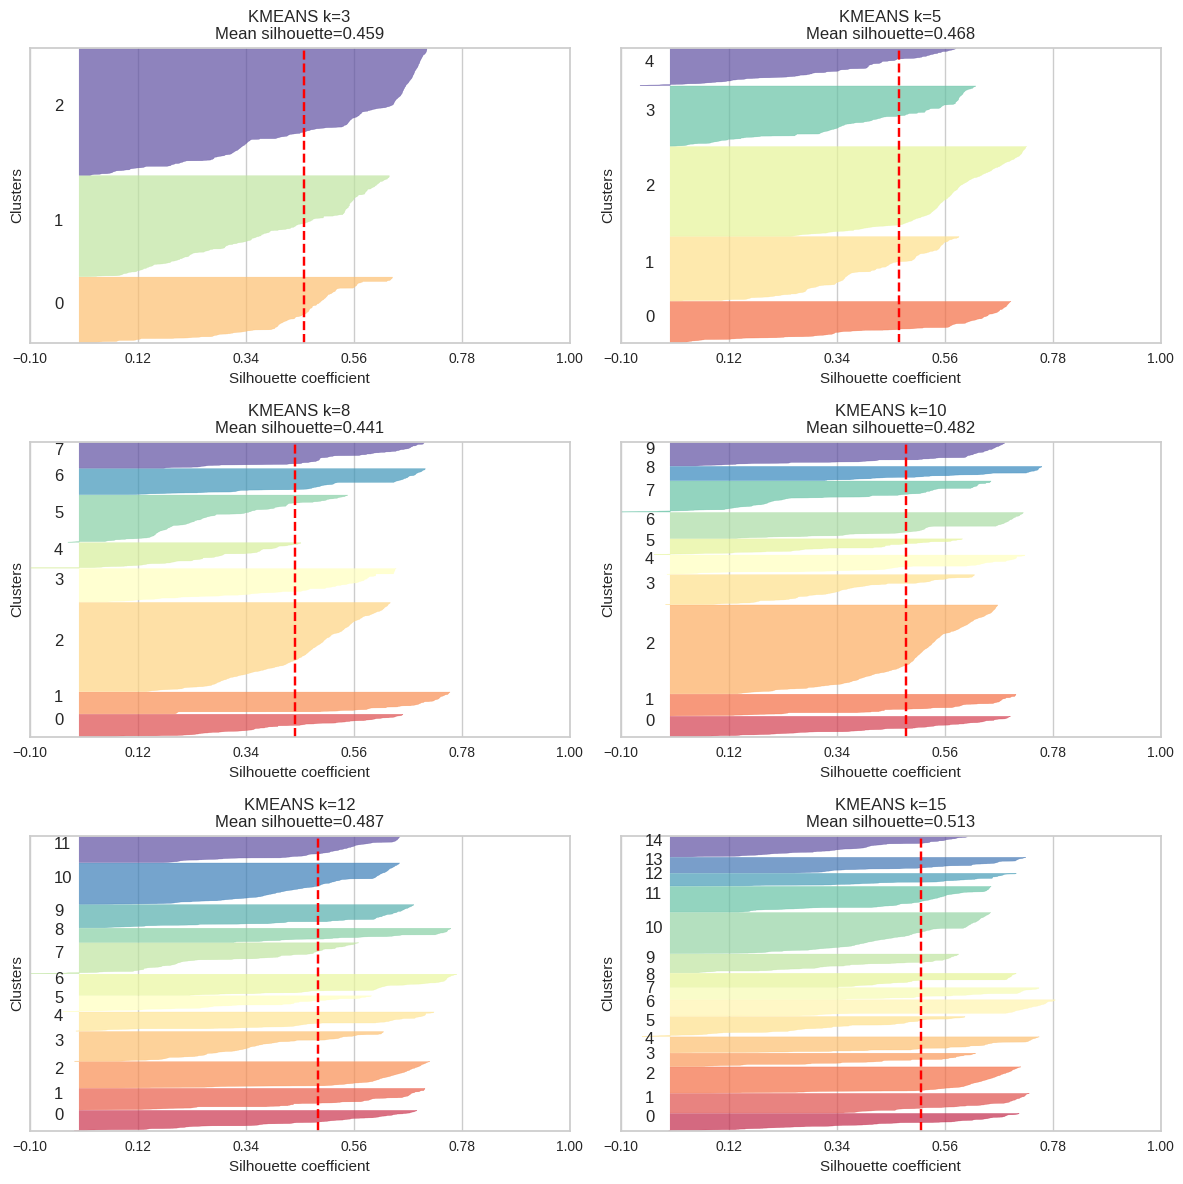

In [131]:
plot_silhouette_facet(embedding_spaces["UMAP (2D)"], clusters=[3, 5, 8, 10, 12, 15])

**Conclusion:**  


The silhouette analysis indicates that cluster quality improves gradually as the number of clusters increases. Although k = 15 achieved the highest average silhouette score (0.513), the improvement over k = 10 (0.482) is relatively small. Since k = 10 provides a more interpretable segmentation while maintaining good cluster separation, it was selected as the final configuration to better support business analysis and decision-making.

# <font color='blue'> 🚀 9.0 Model Training

In [132]:
X = embedding_spaces["UMAP (2D)"].copy()

## <span style="color:blue">9.1</span>  Kmeans

In [134]:
# Define the number of clusters
k = 10

# Model definition 
kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)

# Fit the model
kmeans_model.fit(X)

# Get the cluster labels
labels = kmeans_model.labels_

# Check unique clusters
print(np.unique(labels))

[0 1 2 3 4 5 6 7 8 9]


## <span style="color:blue">9.2</span> Cluster Validation

In [135]:
## WSS (Within-cluster sum of squares)
# print('WSS value: ', model_kmeans.inertia_)

## Silhouette Score
ss = silhouette_score(X, labels, metric='euclidean')
print(f"Silhouette Score (SS): {ss:.3f}")

Silhouette Score (SS): 0.481


# <font color='blue'> 🌐 10.0 Cluster Analysis: Unveiling Hidden Patterns

In [136]:
df10 = df5.copy()
df10['cluster'] = labels
df10.head()

,customer_id,gross_revenue,recency_days,qtde_products,frequency,qtde_returns,cluster
0,17850,5391.21,372.0,297.0,17.000000,40.0,0
1,13047,3232.59,56.0,171.0,0.028302,35.0,4
2,12583,6705.38,2.0,232.0,0.040323,50.0,1
3,13748,948.25,95.0,28.0,0.017921,0.0,4
4,15100,876.00,333.0,3.0,0.073171,22.0,2


## <span style="color:blue">10.2</span> Cluster Profile

In [137]:
# Number os customers
df_cluster = df10[['cluster', 'customer_id']].groupby('cluster').count().reset_index().rename(columns={'customer_id': 'count_customer'})
df_cluster['perc_customer'] = df_cluster['count_customer'] / df_cluster['count_customer'].sum() * 100

# Avg Gross Revenue
df_cluster['avg_gross_revenue'] = df10[['cluster', 'gross_revenue']].groupby('cluster').mean().reset_index()['gross_revenue']

# Avg Recency Days
df_cluster['avg_recency_days'] = df10[['cluster', 'recency_days']].groupby('cluster').mean().reset_index()['recency_days']

# Avg Quantity of Products
df_cluster['avg_qtde_products'] = df10[['cluster', 'qtde_products']].groupby('cluster').mean().reset_index()['qtde_products']

# Avg Frequency
df_cluster['avg_frequency'] = df10[['cluster', 'frequency']].groupby('cluster').mean().reset_index()['frequency']

# Avg Returns
df_cluster['avg_returns'] = df10[['cluster', 'qtde_returns']].groupby('cluster').mean().reset_index()['qtde_returns']


# Store old cluster labels
df_cluster['old_cluster'] = df_cluster['cluster']

# Sort clusters by avg_gross_revenue (descending) and reassign cluster labels
df_cluster = (
    df_cluster
    .sort_values('avg_gross_revenue', ascending=False)
    .reset_index(drop=True)
)

# Assign cluster labels starting from 1
df_cluster['cluster'] = df_cluster.index + 1

# Create mapping dictionary
cluster_map = dict(zip(df_cluster['old_cluster'], df_cluster['cluster']))

# Apply mapping safely
df10['cluster_new'] = df10['cluster'].map(cluster_map)

# Check for unmapped clusters
print("Unmapped clusters:")
print(df10[df10['cluster_new'].isna()]['cluster'].unique())

# Replace old cluster
df10['cluster'] = df10['cluster_new']
df10.drop(columns=['cluster_new'], inplace=True)

# Drop helper column
df_cluster.drop(columns=['old_cluster'], inplace=True)

df_cluster


Unmapped clusters:
[]


,cluster,count_customer,perc_customer,avg_gross_revenue,avg_recency_days,avg_qtde_products,avg_frequency,avg_returns
0,1,825,14.486392,6104.127976,6.122424,236.220606,0.049990,74.030303
1,2,922,16.189640,1809.660683,27.048807,107.749458,0.032102,16.373102
2,3,508,8.920105,1452.534193,68.836614,75.208661,0.025946,10.025591
3,4,426,7.480246,1023.413310,59.553991,97.176056,1.010507,6.734742
4,5,340,5.970149,1020.148265,337.341176,61.388235,0.862909,30.141176
5,6,366,6.426690,981.871093,147.139344,56.021858,0.037320,9.959016
6,7,378,6.637401,899.613333,310.753968,61.854497,0.833050,202.955026
7,8,761,13.362599,690.730749,146.972405,57.069645,1.018397,1.630749
8,9,498,8.744513,601.480602,24.024096,34.616466,1.049029,1.248996
9,10,671,11.782265,528.959270,247.019374,41.959762,1.017884,2.186289


### <span style="color:blue">10.2.1</span> Customer Segmentation Results 


#### 📊 Cluster Profiling (10 Clusters)

Below is the corrected and aligned interpretation of each cluster based on the table provided.

---

##### 🥇 **Cluster 1 – Premium High-Value Customers**
- **Represent:** 14.5% of customers
- **Highest average revenue:** ≈ 6,104
- **Very recent activity:** ≈ 6 days
- **Very high purchase volume:** ≈ 236 products
- **High returns:** ≈ 74

**Profile:**  
The most valuable customer segment, combining the highest revenue, very recent purchases, and strong purchasing activity. Although returns are relatively high, they are proportional to their purchasing volume.

**➡ Top Priority Segment**

---

##### 🥈 **Cluster 2 – Active Mid-Value Customers**
- **Represent:** 16.2% of customers
- **Revenue:** ≈ 1,810
- **Recent activity:** ≈ 27 days
- **High purchase volume:** ≈ 108 products
- **Moderate returns:** ≈ 16

**Profile:**  
Active customers with solid spending and consistent purchasing behavior. A large and valuable segment to retain through loyalty initiatives.

**➡ Retain and Increase Lifetime Value**

---

##### 🥉 **Cluster 3 – Moderate-Value Regular Buyers**
- **Represent:** 8.9% of customers
- **Revenue:** ≈ 1,453
- **Recency:** ≈ 69 days
- **Moderate purchase volume:** ≈ 75 products
- **Low returns:** ≈ 10

**Profile:**  
Customers with moderate revenue and engagement but showing signs of reduced activity.

**➡ Reactivation Opportunity**

---

##### 🔹 **Cluster 4 – Frequent Low-Mid Value Buyers**
- **Represent:** 7.5% of customers
- **Revenue:** ≈ 1,023
- **Recency:** ≈ 60 days
- **High purchase volume:** ≈ 97 products
- **Low returns:** ≈ 7

**Profile:**  
Customers with frequent purchases and relatively low operational cost, despite generating moderate revenue.

**➡ Retain Through Engagement**

---

##### 🔹 **Cluster 5 – Dormant High-Return Customers**
- **Represent:** 6.0% of customers
- **Revenue:** ≈ 1,020
- **Very long recency:** ≈ 337 days
- **Moderate purchase volume:** ≈ 61 products
- **High returns:** ≈ 30

**Profile:**  
Previously active customers who have become inactive and exhibit relatively high return rates.

**➡ Churn Risk – Reactivation Campaigns**

---

##### 🔹 **Cluster 6 – Inactive Moderate Buyers**
- **Represent:** 6.4% of customers
- **Revenue:** ≈ 982
- **Long recency:** ≈ 147 days
- **Moderate purchase volume:** ≈ 56 products
- **Low returns:** ≈ 10

**Profile:**  
Customers with moderate historical value but low recent engagement.

**➡ Win-Back Opportunity**

---

##### 🔹 **Cluster 7 – High-Return Heavy Buyers**
- **Represent:** 6.6% of customers
- **Revenue:** ≈ 900
- **Very long recency:** ≈ 311 days
- **Moderate purchase volume:** ≈ 62 products
- **Extremely high returns:** ≈ 203

**Profile:**  
Customers with exceptionally high return rates and low recent activity, making them operationally expensive.

**➡ High Operational Risk**

---

##### 🔹 **Cluster 8 – Low-Value Frequent Buyers**
- **Represent:** 13.4% of customers
- **Revenue:** ≈ 691
- **Long recency:** ≈ 147 days
- **Moderate purchase volume:** ≈ 57 products
- **Very low returns:** ≈ 2

**Profile:**  
Large customer segment with low spending but low operational cost.

**➡ Maintain with Low-Cost Campaigns**

---

##### ⚠️ **Cluster 9 – Low-Value Recent Customers**
- **Represent:** 8.7% of customers
- **Revenue:** ≈ 601
- **Recent activity:** ≈ 24 days
- **Low purchase volume:** ≈ 35 products
- **Minimal returns:** ≈ 1

**Profile:**  
Low-spending customers who remain active and may have potential for future growth.

**➡ Upselling Opportunity**

---

##### ❌ **Cluster 10 – Low-Value Infrequent Buyers**
- **Represent:** 11.8% of customers
- **Revenue:** ≈ 529
- **Long recency:** ≈ 247 days
- **Low purchase volume:** ≈ 42 products
- **Very low returns:** ≈ 2

**Profile:**  
Low-value customers with infrequent purchases and limited recent engagement.

**➡ Lowest Priority Segment**

---

# <font color='blue'> ✨ 11.0 Deploy to Production

## 11.1 Insert Into SQLITE

In [113]:
# create table
import sqlite3

from sqlalchemy import create_engine

In [114]:
df10.dtypes

customer_id        int64
gross_revenue    float64
recency_days       int64
qtde_products      int64
frequency        float64
qtde_returns       int64
cluster            int64
dtype: object

In [115]:
# change dtypes
df10['recency_days'] = df10['recency_days'].astype(int)
df10['qtde_products'] = df10['qtde_products'].astype(int)
df10['qtde_returns'] = df10['qtde_returns'].astype(int)

In [116]:

query_create_table_insiders = """
CREATE TABLE IF NOT EXISTS insiders (
    customer_id       INTEGER,
    gross_revenue     FLOAT,
    recency_days      INTEGER,
    qtde_products     INTEGER,
    frequency         FLOAT,
    qtde_returns      INTEGER,
    cluster           INTEGER
)
    
"""

conn = sqlite3.connect('../data/processed/insiders_db.sqlite')
conn.execute(query_create_table_insiders)
conn.commit()

# insert data with sqlalhemy    
create_engine('sqlite:///../data/processed/insiders_db.sqlite')
df10.to_sql('insiders', con=conn, if_exists='replace', index=False)

2969

In [117]:
# consulting database
query = """ SELECT * FROM insiders; """
df_insiders = pd.read_sql(query, con=conn)

df_insiders.head()

df_insiders.shape

(2969, 7)